## SVM

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


#### Load the data

In [2]:
data = pd.read_excel('../Data/Data_finance_lab3.xlsx', sheet_name='data_final')
data.head()

,APP_ID,DISBURSALDATE,REPORT_DATE,TERM_TMP,PRODUCT_NAME,LOANAMOUNT_NOT_INSURANCE,INSURANCE_FEE,LA,EFF_RATE,TERM,...,PERSONAL_INCOME,ADDITIONAL_INCOME,PERSONAL_EXPENSE,FAMILY_INCOME,FAMILY_EXPENSE,MARITAL_STATUS,EDUCATION,City,ADDRESS_CURRENT_CITY,PROVINCE_CURRENT
0,16499318,2017-10-10,2018-10-26,12,FC UP DSA TS SCORE 2 NEW- 762,18000000,990000,18990000,45.0,24,...,9000000,0,9600000,20000000,5000000,Other,High School,Tỉnh Yên Bái,Yên Bình,Tỉnh Yên Bái
1,16490594,2017-10-10,2018-10-26,12,FC UP L.G 2 TSA SCORE NEW- 617,10000000,550000,10550000,44.5,12,...,5500000,0,7200000,15000000,4000000,Married,High School,Tỉnh Quảng Ninh,Đông Triều,Tỉnh Quảng Ninh
2,16910227,2017-10-28,2018-10-26,11,FC UP CAT B NEW- 610,25000000,1375000,26375000,47.0,24,...,5182000,0,12000000,5200000,1000000,Single,Middle School,Tỉnh Bình Dương,Tân Uyên,Tỉnh Bình Dương
3,16355347,2017-10-04,2018-10-26,12,FC UP L.G 2 TSA SCORE NEW- 617,30000000,1650000,31650000,44.5,24,...,10000000,0,18000000,20000000,6000000,Married,Middle School,Tỉnh An Giang,Phú Tân,Tỉnh An Giang
4,16705974,2017-10-18,2018-10-26,12,FC UP L.G 2 TSA SCORE NEW- 617,20000000,1100000,21100000,44.5,18,...,7000000,0,12000000,20000000,7000000,Single,High School,Thành phố Hải Phòng,Vĩnh Bảo,Thành phố Hải Phòng


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   APP_ID                    5000 non-null   int64         
 1   DISBURSALDATE             5000 non-null   datetime64[ns]
 2   REPORT_DATE               5000 non-null   datetime64[ns]
 3   TERM_TMP                  5000 non-null   int64         
 4   PRODUCT_NAME              5000 non-null   object        
 5   LOANAMOUNT_NOT_INSURANCE  5000 non-null   int64         
 6   INSURANCE_FEE             5000 non-null   int64         
 7   LA                        5000 non-null   int64         
 8   EFF_RATE                  5000 non-null   float64       
 9   TERM                      5000 non-null   int64         
 10  COUNT_TERM_RECEIPT        4909 non-null   float64       
 11  flag term                 4909 non-null   float64       
 12  SUM_RECEIPT_AMT     

In [4]:
missing_values = data.isnull().sum()
missing_values

APP_ID                         0
DISBURSALDATE                  0
REPORT_DATE                    0
TERM_TMP                       0
PRODUCT_NAME                   0
LOANAMOUNT_NOT_INSURANCE       0
INSURANCE_FEE                  0
LA                             0
EFF_RATE                       0
TERM                           0
COUNT_TERM_RECEIPT            91
flag term                     91
SUM_RECEIPT_AMT               91
Unnamed: 13                 4849
flag loan amt                 91
flag final                    91
RESULT_YES/NO                  0
EMI                            0
GENDER                         0
AGE                            0
Number of Children          4200
PERSONAL_INCOME                0
ADDITIONAL_INCOME              0
PERSONAL_EXPENSE               0
FAMILY_INCOME                  0
FAMILY_EXPENSE                 0
MARITAL_STATUS                 0
EDUCATION                      0
City                           0
ADDRESS_CURRENT_CITY           0
PROVINCE_C

In [5]:
# Cast columns to appropriate data types
data['RESULT_YES/NO'] = data['RESULT_YES/NO'].astype('object')

In [6]:
data['INCOME'] = data['PERSONAL_INCOME'] + data['ADDITIONAL_INCOME'] + data['FAMILY_INCOME'] - data['FAMILY_EXPENSE'] - data['PERSONAL_EXPENSE']

In [7]:
# Create a new column BAD_DEBT base on the COUNT_TERM_RECEIPT and SUM_RECEIPT_AMT columns
data['BAD_DEBT'] = data[['COUNT_TERM_RECEIPT', 'SUM_RECEIPT_AMT']].isna().all(axis=1).astype(int)
data['BAD_DEBT'] = data['BAD_DEBT'].astype('category')

In [8]:
# Fill missing values

data['COUNT_TERM_RECEIPT'] = data['COUNT_TERM_RECEIPT'].fillna(0)
data['SUM_RECEIPT_AMT'] = data['SUM_RECEIPT_AMT'].fillna(0)
data['Number of Children'] = data['Number of Children'].fillna(0)

data.isnull().sum()


APP_ID                         0
DISBURSALDATE                  0
REPORT_DATE                    0
TERM_TMP                       0
PRODUCT_NAME                   0
LOANAMOUNT_NOT_INSURANCE       0
INSURANCE_FEE                  0
LA                             0
EFF_RATE                       0
TERM                           0
COUNT_TERM_RECEIPT             0
flag term                     91
SUM_RECEIPT_AMT                0
Unnamed: 13                 4849
flag loan amt                 91
flag final                    91
RESULT_YES/NO                  0
EMI                            0
GENDER                         0
AGE                            0
Number of Children             0
PERSONAL_INCOME                0
ADDITIONAL_INCOME              0
PERSONAL_EXPENSE               0
FAMILY_INCOME                  0
FAMILY_EXPENSE                 0
MARITAL_STATUS                 0
EDUCATION                      0
City                           0
ADDRESS_CURRENT_CITY           0
PROVINCE_C

In [9]:
data.drop(['Unnamed: 13', 'flag loan amt', 'flag final', 'flag term'], axis=1, inplace=True)

### Handle datetime variables

In [10]:
datetime_vars = data.select_dtypes(include='datetime').columns
datetime_vars

Index(['DISBURSALDATE', 'REPORT_DATE'], dtype='object')

In [11]:
from scipy.stats import pearsonr, spearmanr

data['TIME_DELTA'] = data['DISBURSALDATE'] - data['REPORT_DATE']
data['TIME_DELTA'] = data['TIME_DELTA'].dt.days

data['DISBURSALDATE_days'] = data['DISBURSALDATE'].dt.day

corr, _ = spearmanr(data['TIME_DELTA'], data['RESULT_YES/NO'])
print('Spearmans correlation: %.3f' % corr)
corr, _ = spearmanr(data['DISBURSALDATE_days'], data['RESULT_YES/NO'])
print('Spearmans correlation: %.3f' % corr)

Spearmans correlation: -0.161
Spearmans correlation: -0.161


### Handle Categorical Variables

In [12]:
categorical_vars = data.select_dtypes(include=['object', 'category']).columns.tolist()
categorical_vars


['PRODUCT_NAME',
 'RESULT_YES/NO',
 'GENDER',
 'MARITAL_STATUS',
 'EDUCATION',
 'City',
 'ADDRESS_CURRENT_CITY',
 'PROVINCE_CURRENT',
 'BAD_DEBT']

In [13]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt

results = []
for var in categorical_vars:
    if var == 'RESULT_YES/NO':
        continue
    
    contingency_table = pd.crosstab(data[var], data['RESULT_YES/NO'])
    
    chi2, p, _, expected = chi2_contingency(contingency_table)
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape
    
    cramers_v = np.sqrt(chi2 / (n * (min(r, k) - 1)))
    
    results.append({
        'Variable': var,
        'Chi-squared': chi2,
        'p-value': p,
        'Cramér\'s V': cramers_v
    })

results_df = pd.DataFrame(results)
results_df.sort_values(by='Cramér\'s V', ascending=False, inplace=True)
results_df


,Variable,Chi-squared,p-value,Cramér's V
0,PRODUCT_NAME,806.541006,2.123441e-82,0.401632
5,ADDRESS_CURRENT_CITY,778.073358,1.145264e-04,0.394480
7,BAD_DEBT,243.354932,7.297958e-55,0.220615
4,City,155.786224,3.183290e-09,0.176514
6,PROVINCE_CURRENT,155.786224,3.183290e-09,0.176514
3,EDUCATION,43.659298,2.487469e-07,0.093444
2,MARITAL_STATUS,17.533882,1.521684e-03,0.059218
1,GENDER,0.165716,6.839477e-01,0.005757


### Handle numerical variables

In [14]:
numerical_vars = data.select_dtypes(include=[np.number]).columns.to_list()
numerical_vars

['APP_ID',
 'TERM_TMP',
 'LOANAMOUNT_NOT_INSURANCE',
 'INSURANCE_FEE',
 'LA',
 'EFF_RATE',
 'TERM',
 'COUNT_TERM_RECEIPT',
 'SUM_RECEIPT_AMT',
 'EMI',
 'AGE',
 'Number of Children',
 'PERSONAL_INCOME',
 'ADDITIONAL_INCOME',
 'PERSONAL_EXPENSE',
 'FAMILY_INCOME',
 'FAMILY_EXPENSE',
 'INCOME',
 'TIME_DELTA',
 'DISBURSALDATE_days']

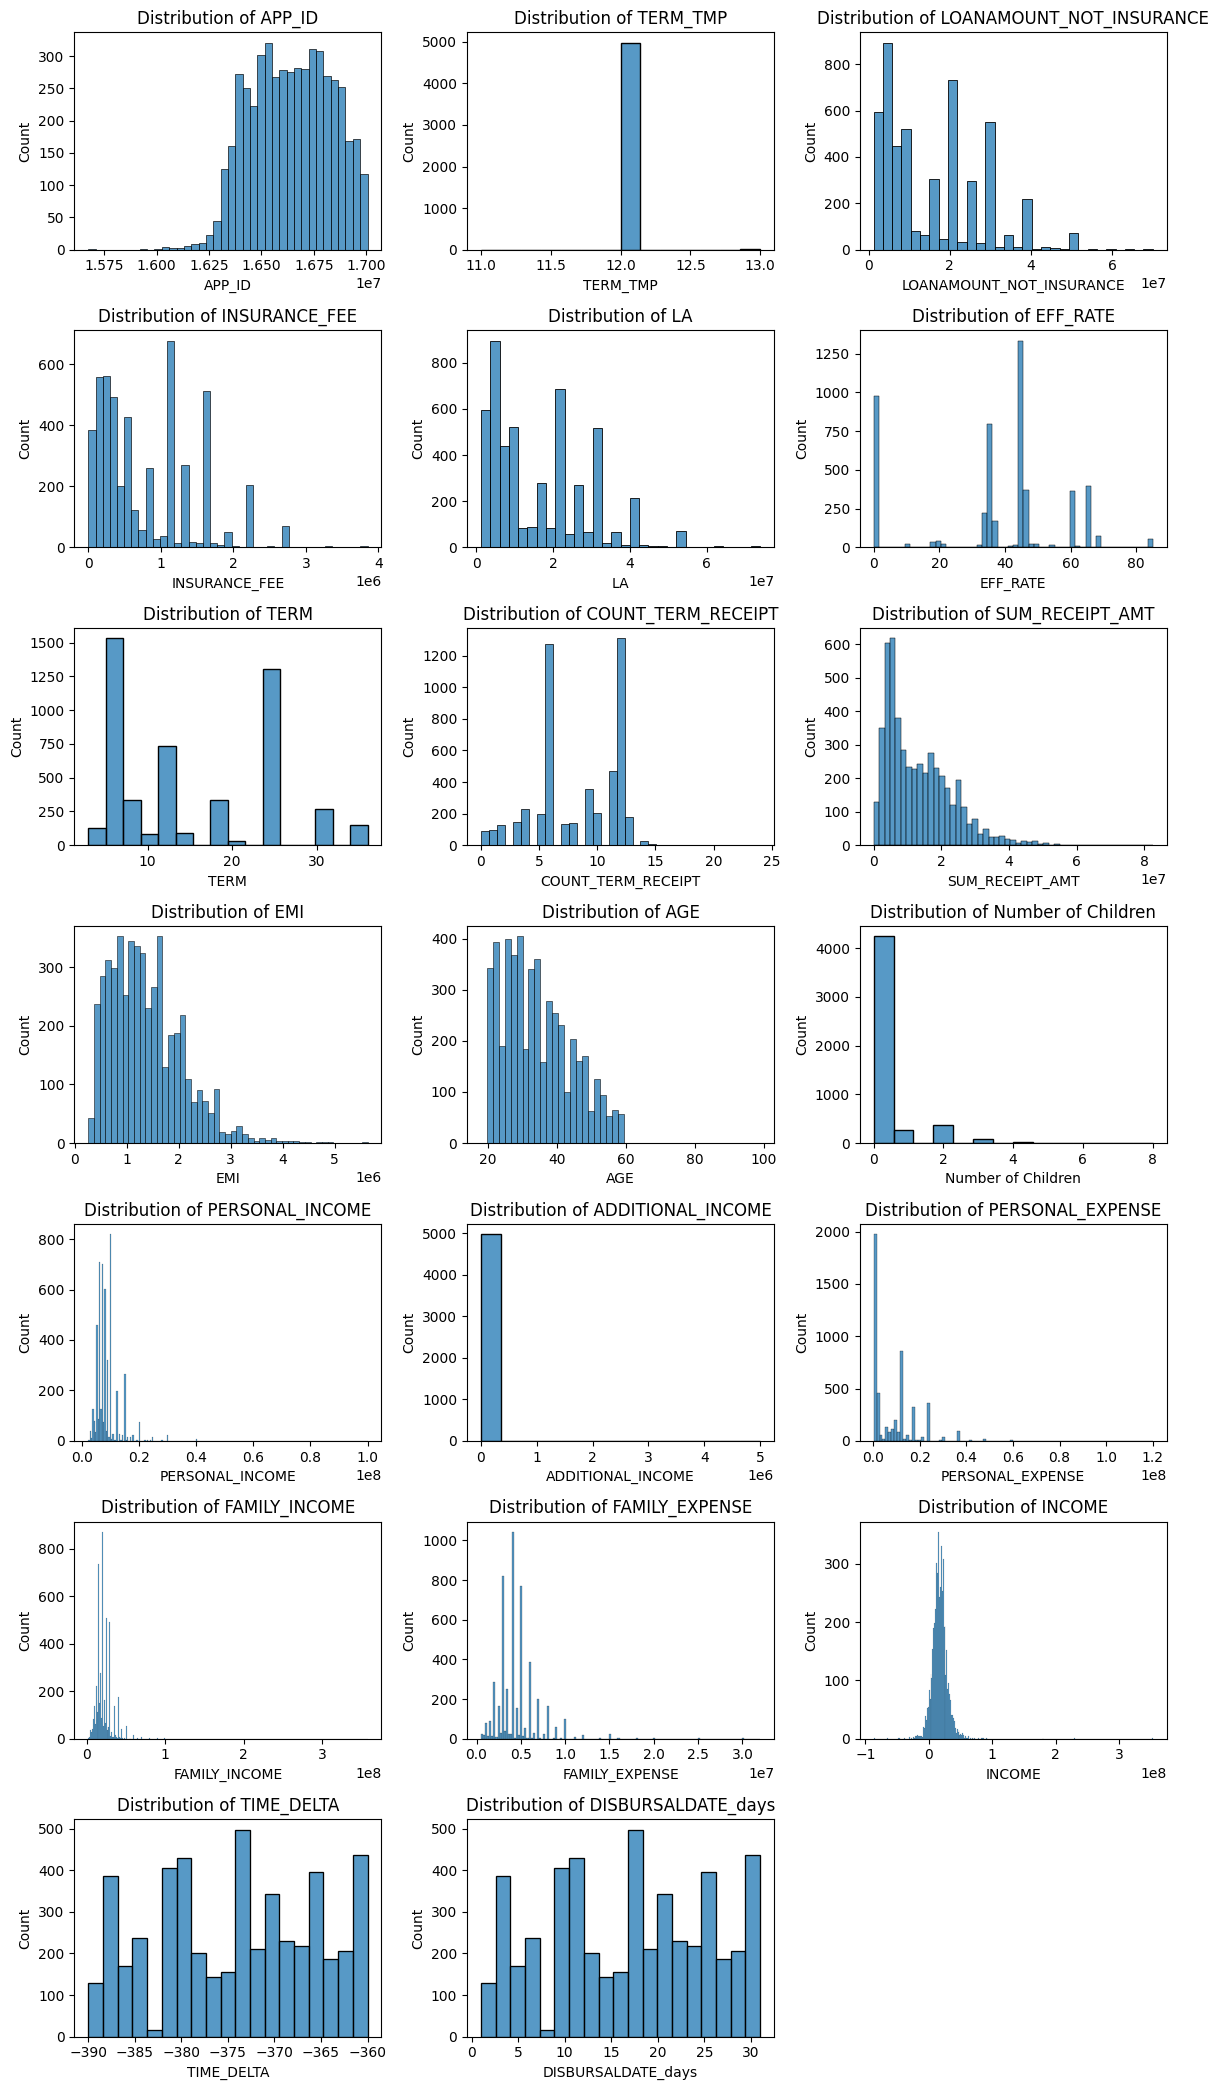

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

n_cols = 3
n_rows = math.ceil(len(numerical_vars) / n_cols)  

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3 * n_rows))  
axes = axes.flatten()  

for i, var in enumerate(numerical_vars):
    sns.histplot(x=data[var], ax=axes[i])
    axes[i].set_title(f'Distribution of {var}')

for j in range(len(numerical_vars), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


In [16]:
for var in numerical_vars:
    skewness = data[var].skew()
    print(f'{var}: Skewness = {skewness}')


APP_ID: Skewness = -0.1259821968250477
TERM_TMP: Skewness = 14.722286844523575
LOANAMOUNT_NOT_INSURANCE: Skewness = 0.8742182908882028
INSURANCE_FEE: Skewness = 0.9127218920515116
LA: Skewness = 0.8771667431983788
EFF_RATE: Skewness = -0.5532877689010144
TERM: Skewness = 0.5051030440472818
COUNT_TERM_RECEIPT: Skewness = -0.3290766826431325
SUM_RECEIPT_AMT: Skewness = 1.2525323208465344
EMI: Skewness = 0.9701741161327685
AGE: Skewness = 0.582072113337616
Number of Children: Skewness = 3.052565539716042
PERSONAL_INCOME: Skewness = 4.4923896213998225
ADDITIONAL_INCOME: Skewness = 24.039534244308086
PERSONAL_EXPENSE: Skewness = 2.1374613145710635
FAMILY_INCOME: Skewness = 7.939143178397916
FAMILY_EXPENSE: Skewness = 2.7800974208581573
INCOME: Skewness = 4.462441173405926
TIME_DELTA: Skewness = -0.05556652148294667
DISBURSALDATE_days: Skewness = -0.05556652148294916


In [17]:
results = []
for var in numerical_vars:
    if var != 'RESULT_YES/NO':  
        spearman_corr = data[var].corr(data['RESULT_YES/NO'], method='spearman')
        results.append({
            'Variable': var,
            'Spearman Correlation': spearman_corr,
        })

results_df = pd.DataFrame(results)
results_df.sort_values(by='Spearman Correlation', ascending=False, inplace=True)
results_df

,Variable,Spearman Correlation
7,COUNT_TERM_RECEIPT,0.214659
11,Number of Children,0.144249
17,INCOME,0.116854
8,SUM_RECEIPT_AMT,0.017173
13,ADDITIONAL_INCOME,0.013643
10,AGE,-0.050646
1,TERM_TMP,-0.064722
16,FAMILY_EXPENSE,-0.098279
0,APP_ID,-0.113054
12,PERSONAL_INCOME,-0.132580


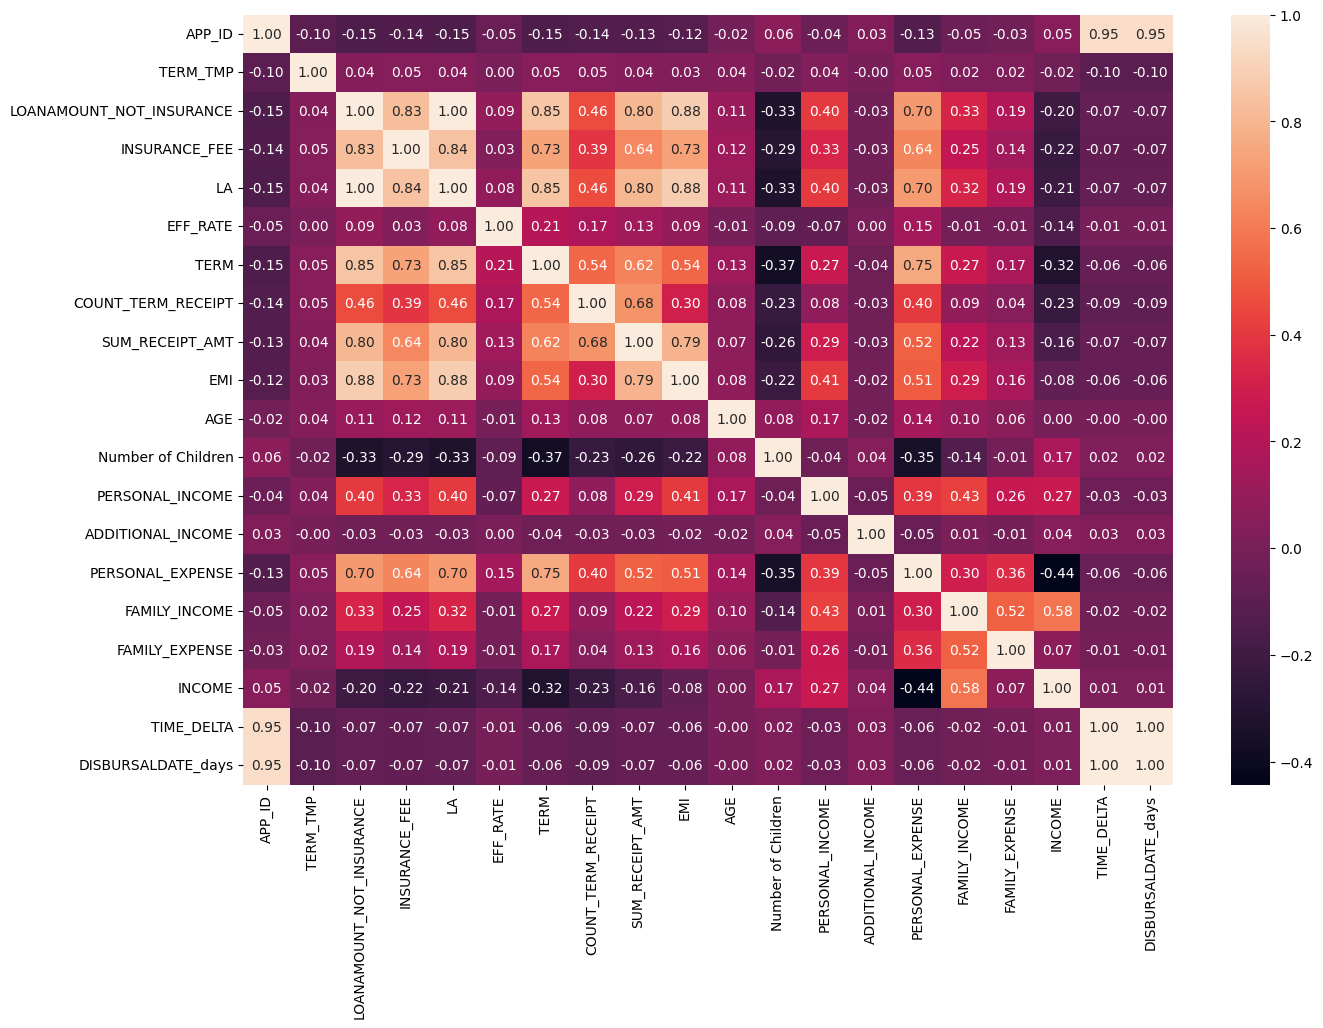

In [18]:
corr_matrix = data[numerical_vars].corr(method='spearman')
plt.figure(figsize=(15,10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f')
plt.show()

### Outliers detection

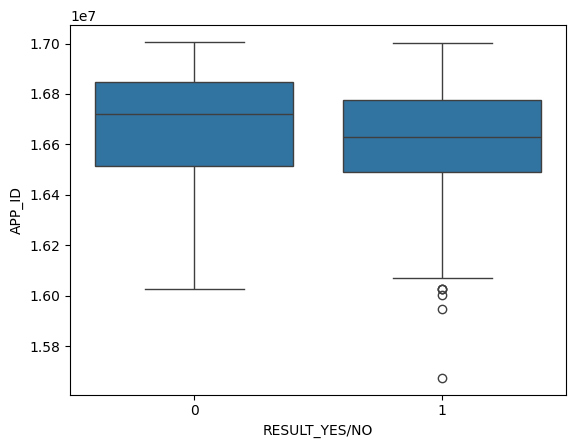

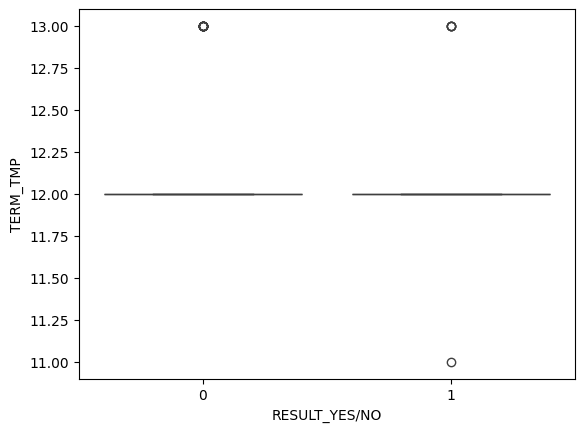

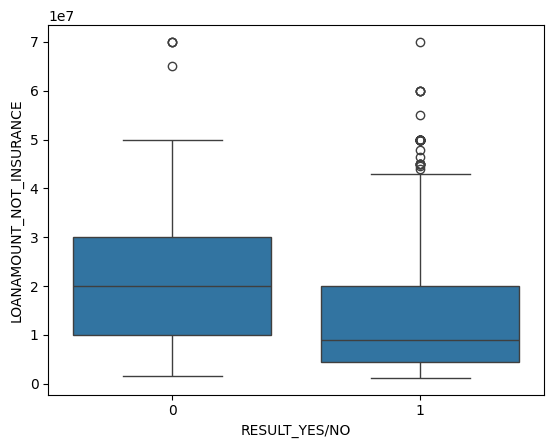

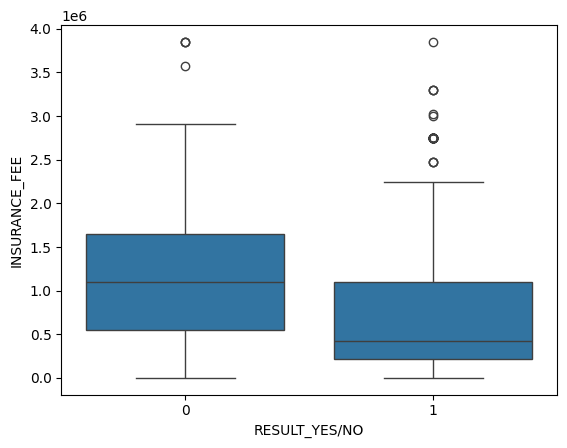

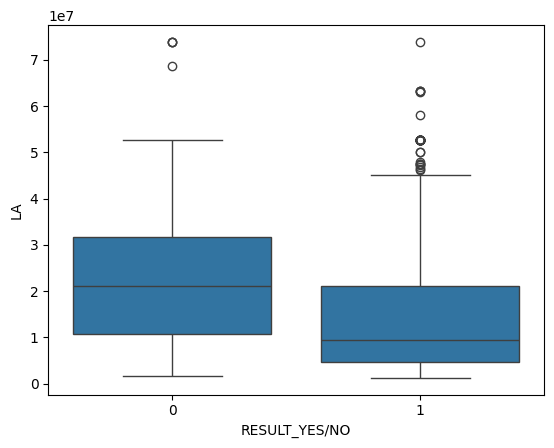

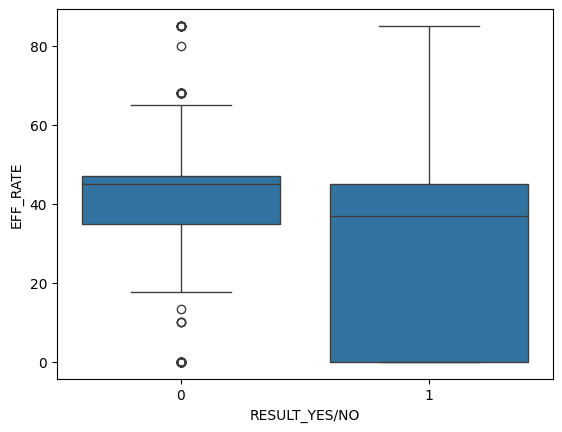

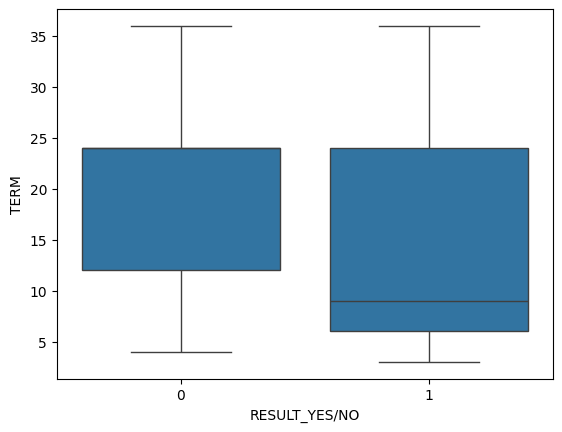

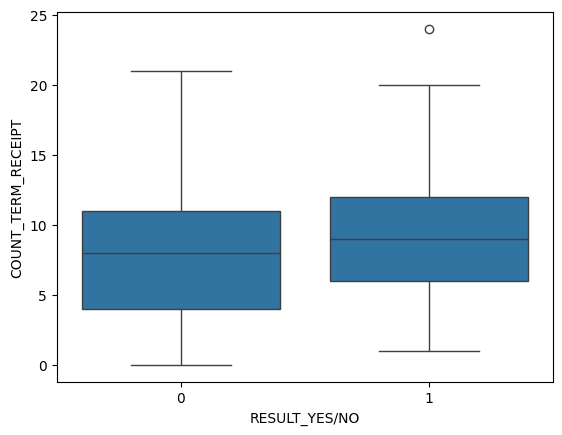

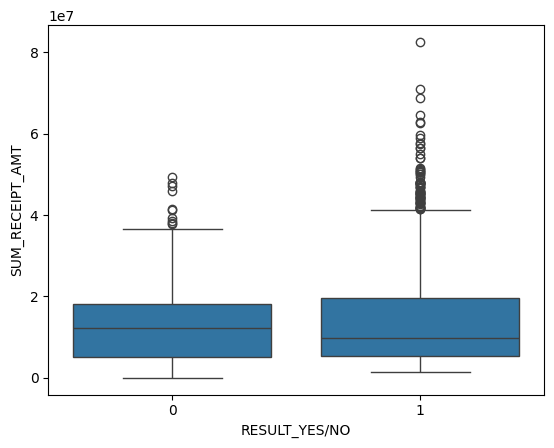

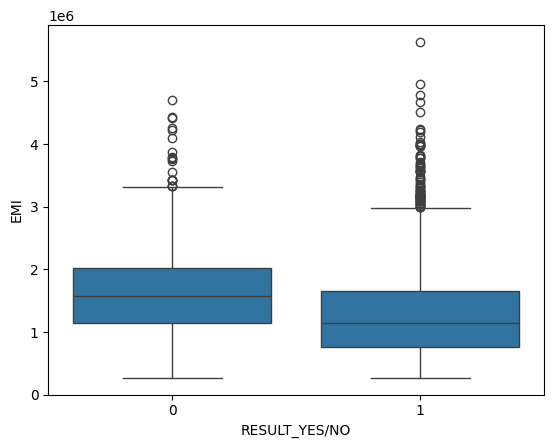

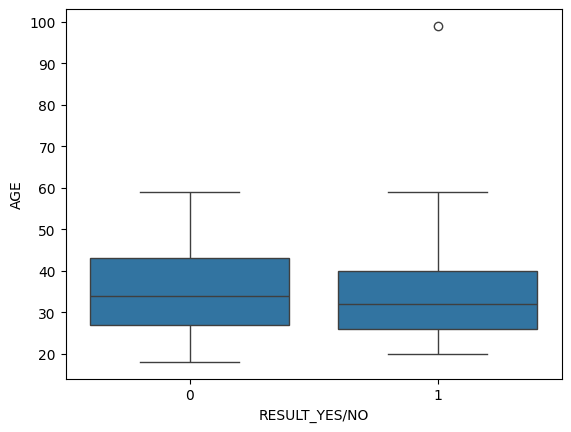

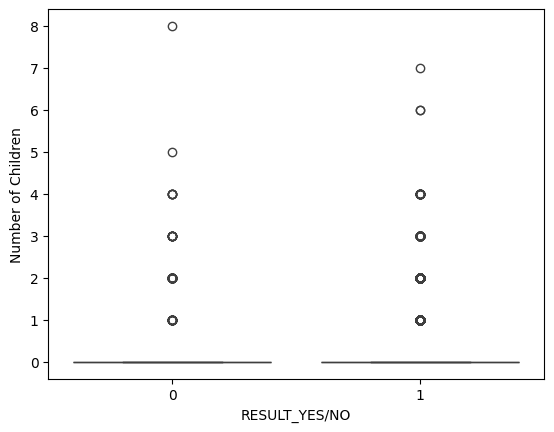

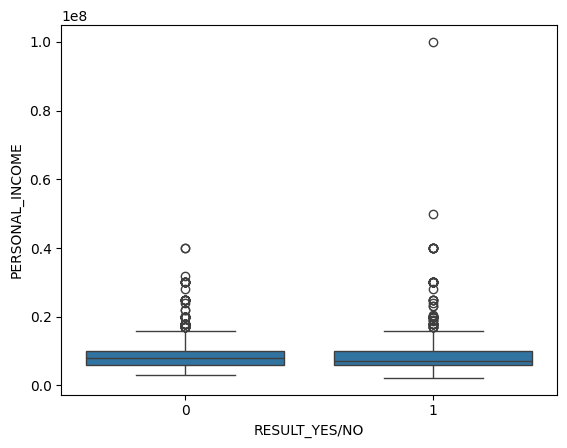

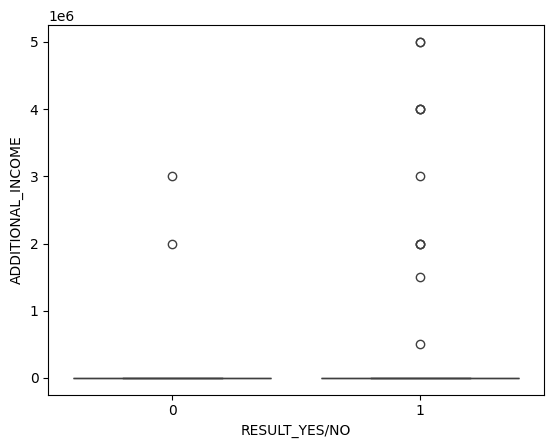

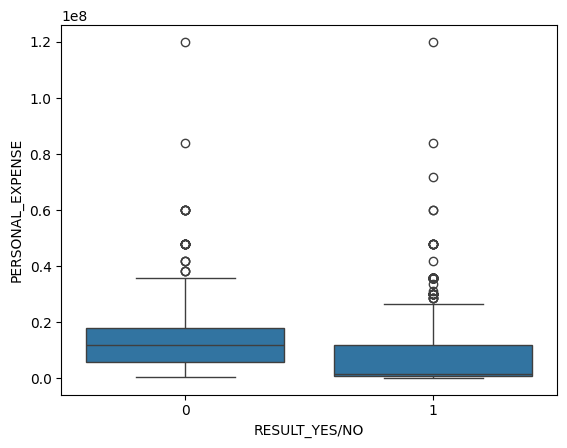

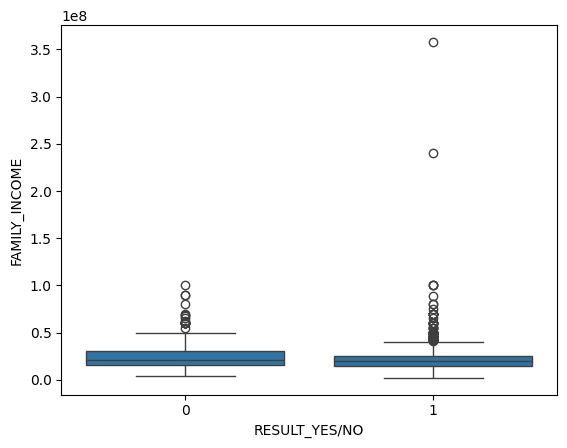

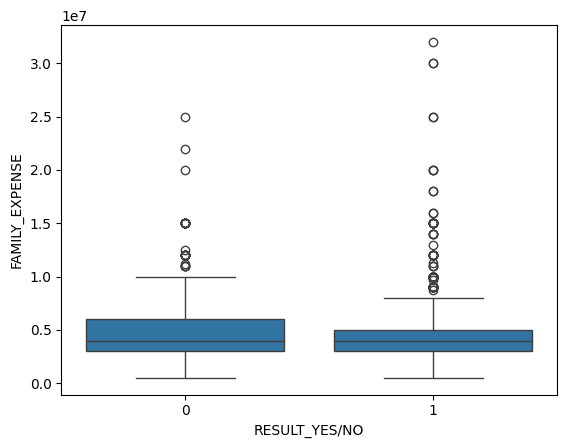

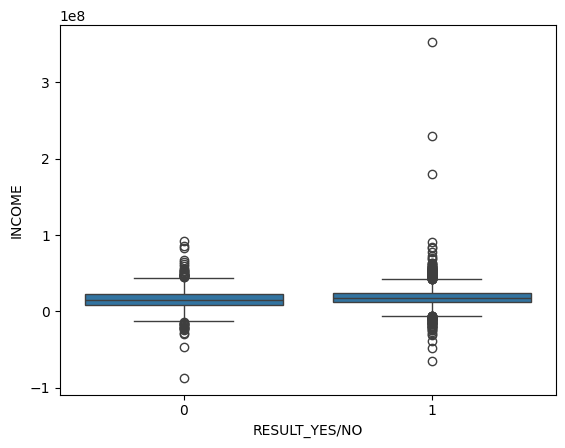

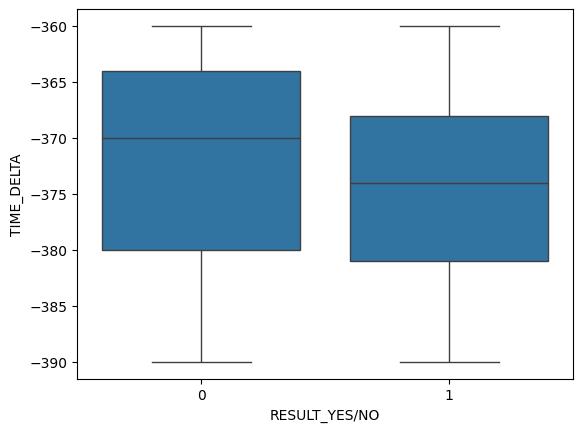

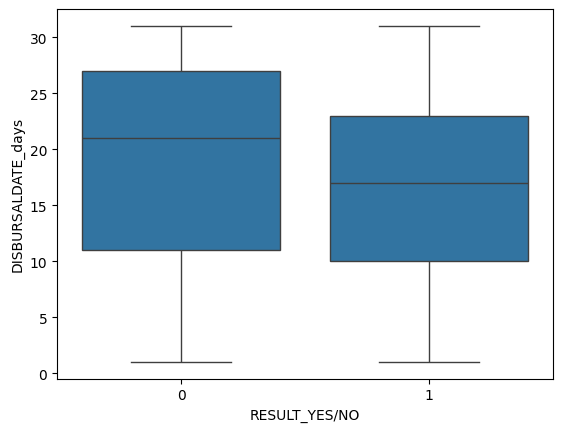

In [19]:
for var in numerical_vars:
    sns.boxplot(x='RESULT_YES/NO', y=var, data=data)
    plt.show()


### Preprocessing

In [20]:
_data = data.copy()

epsilon = 1e-6
_data['I1'] = _data['SUM_RECEIPT_AMT'] / (_data['COUNT_TERM_RECEIPT'] + epsilon)
# _data['TERM'] = _data['TERM'].astype('category')

In [21]:
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler


def normalize_data(_data):
    print(_data['LA'].mean())
    print(_data['TERM'].mean())
    numerical_vars = _data.select_dtypes(include=[np.number]).columns.to_list()

    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(_data[numerical_vars])

    freq_encoding = _data['PRODUCT_NAME'].value_counts(normalize=True)
    _data['PRODUCT_NAME'] = _data['PRODUCT_NAME'].map(freq_encoding)

    for i, var in enumerate(numerical_vars):
        _data[var] = scaled_features[:, i]

    return scaler, freq_encoding


In [22]:
def apply_normalization(_data, scaler, freq_encoding):
    numerical_vars = _data.select_dtypes(include=[np.number]).columns.to_list()

    scaled_features = scaler.transform(_data[numerical_vars])

    for i, var in enumerate(numerical_vars):
        _data[var] = scaled_features[:, i]

    _data['PRODUCT_NAME'] = _data['PRODUCT_NAME'].map(freq_encoding).fillna(0)

    return _data

In [23]:
def replace_outliers_with_mean(data, attributes):
    data_no_outliers = data.copy()

    for attribute in attributes:
        Q1 = data[attribute].quantile(0.25)
        Q3 = data[attribute].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        mean_value = data_no_outliers[(data_no_outliers[attribute] >= lower_bound) & 
                                      (data_no_outliers[attribute] <= upper_bound)][attribute].mean()

        data_no_outliers.loc[(data_no_outliers[attribute] < lower_bound) | 
                             (data_no_outliers[attribute] > upper_bound), attribute] = mean_value

    return data_no_outliers


In [24]:
from sklearn.svm import OneClassSVM
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

normal_data = _data[_data['RESULT_YES/NO'] == 1]
anomaly_data = _data[_data['RESULT_YES/NO'] == 0]
normal_train, normal_test = train_test_split(normal_data, test_size=0.2, random_state=42)
test_data = pd.concat([normal_test, anomaly_data])


columns = _data.columns.to_list()
columns_train = [
    'SUM_RECEIPT_AMT', 
    'COUNT_TERM_RECEIPT', 
    'TERM',
    'LA',
    'PRODUCT_NAME',
    'BAD_DEBT',
    'RESULT_YES/NO'
]

columns_train = columns_train 

drop_columns = list(set(columns).symmetric_difference(set(columns_train)))

X = normal_train.drop(columns=drop_columns) 
X_train = X
scaler, freq_encoding = normalize_data(X_train)
X_train.drop(columns=['RESULT_YES/NO'], inplace=True)
y_train = normal_train['RESULT_YES/NO']



test_data, val_data = train_test_split(test_data, test_size=0.5, random_state=42)

X = test_data.drop(columns=drop_columns)
X_test = X
apply_normalization(X_test, scaler, freq_encoding)
X_test.drop(columns=['RESULT_YES/NO'], inplace=True)
y_test = test_data['RESULT_YES/NO'].astype(int)

X = val_data.drop(columns=drop_columns)
X_val = X
apply_normalization(X_val, scaler, freq_encoding)
X_val = X_val.drop(columns=['RESULT_YES/NO'])
y_val = val_data['RESULT_YES/NO'].astype(int)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

14242970.936038515
13.35866574965612
(2908, 6) (2908,)
(1046, 6) (1046,)


### Find the best model by using GridSearchCV

In [25]:
from sklearn.svm import OneClassSVM
from sklearn.metrics import precision_recall_curve, auc

nu_values = [
    0.01, 0.05, 0.1, 0.2, 0.5
]
gamma_values = [
    1, 5, 10, 20, 25, 30
]

best_pr_auc = 0
best_params = {}

for nu in nu_values:
    for gamma in gamma_values:
        model = OneClassSVM(kernel='rbf', nu=nu, gamma=gamma)
        model.fit(X_train)
        
        y_scores = model.decision_function(X_val)
        
        precisions, recalls, _ = precision_recall_curve(y_val, y_scores)
        pr_auc = auc(recalls, precisions)
        
        if pr_auc > best_pr_auc:
            best_pr_auc = pr_auc
            best_params = {'nu': nu, 'gamma': gamma}

print(f"Best PR AUC: {best_pr_auc}")
print(f"Best Parameters: {best_params}")


Best PR AUC: 0.8834854301766596
Best Parameters: {'nu': 0.5, 'gamma': 25}


### Model Evaluation

In [26]:
from sklearn.metrics import precision_recall_curve, average_precision_score, auc

import matplotlib.pyplot as plt

oc_svm = OneClassSVM(kernel='rbf', gamma=best_params.get('gamma'), nu=best_params.get('nu'))
oc_svm.fit(X_train)



OneClassSVM(gamma=25)

### Test data and plot the precision-recall curve

Precio-Recall AUC: 0.8589723232402939
              precision    recall  f1-score   support

           0       0.89      0.93      0.91       694
           1       0.84      0.78      0.81       352

    accuracy                           0.88      1046
   macro avg       0.87      0.86      0.86      1046
weighted avg       0.88      0.88      0.88      1046

Average Precision: 0.7344592450368934


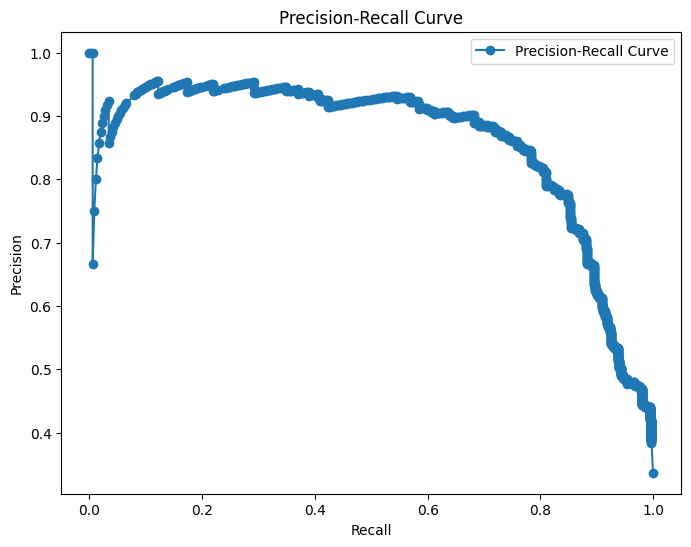

In [27]:
decision_scores = oc_svm.decision_function(X_test)  
precision, recall, thresholds = precision_recall_curve(y_test, decision_scores)

epsilon = 1e-10
f1_scores = 2 * (precision * recall) / (precision + recall + epsilon)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

auc_score = auc(recall, precision)
print(f'Precio-Recall AUC: {auc_score}')

y_pred_new = (decision_scores >= optimal_threshold).astype(int)
average_precision = average_precision_score(y_test, y_pred_new)
report = classification_report(y_test, y_pred_new)
print(report)
print(f"Average Precision: {average_precision}")


plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='o', label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

### Save the model

In [28]:
### save the model
import joblib

joblib.dump(oc_svm, 'oc_svm_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(freq_encoding, 'freq_encoding_product_name.joblib')

['freq_encoding_product_name.joblib']